# 9. Practical Training Challenges
---
Real neural networks face several common issues that prevent training from working well. This notebook covers the most important ones — and how to fix them.


## 9.0 The Vanishing Gradient Problem (Preview)

When you stack sigmoid/tanh layers, gradients get **multiplied** during backprop.  
Since sigmoid derivatives are at most 0.25, gradients shrink exponentially:

$$0.25^{10} \approx 0.000001$$

Early layers receive **almost no gradient signal** → they don't learn!

**ReLU** avoids this because its derivative is either 0 or 1 (for positive inputs).


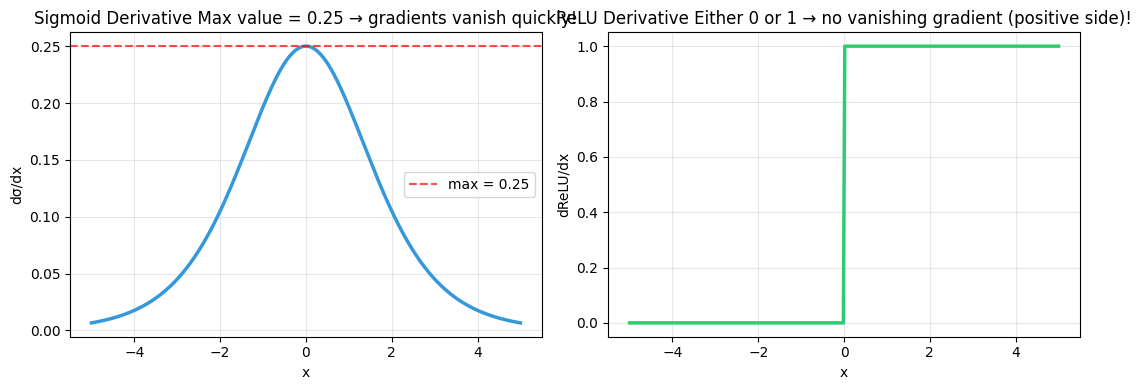

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# All activation functions
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x):    return np.tanh(x)
def relu(x):    return np.maximum(0, x)
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)
def gelu(x):    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

# Visualizing vanishing gradients across layers
def sigmoid_derivative(x): 
    return sigmoid(x) * (1 - sigmoid(x))
def relu_derivative(x): 
    return (x > 0).astype(float)

x_range = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Sigmoid derivative
axes[0].plot(x_range, sigmoid_derivative(x_range), color='#3498DB', lw=2.5)
axes[0].set_title("Sigmoid Derivative Max value = 0.25 → gradients vanish quickly!")
axes[0].set_xlabel("x"); axes[0].set_ylabel("dσ/dx")
axes[0].axhline(0.25, color='red', linestyle='--', alpha=0.7, label='max = 0.25')
axes[0].legend(); axes[0].grid(alpha=0.3)

# ReLU derivative
axes[1].plot(x_range, relu_derivative(x_range), color='#2ECC71', lw=2.5)
axes[1].set_title("ReLU Derivative Either 0 or 1 → no vanishing gradient (positive side)!")
axes[1].set_xlabel("x"); axes[1].set_ylabel("dReLU/dx")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9.1 Vanishing & Exploding Gradients

During backprop, gradients are **multiplied** at each layer.

- If values < 1 repeatedly: gradients **vanish** → early layers don't learn
- If values > 1 repeatedly: gradients **explode** → weights blow up → NaN

This is especially bad for deep networks (>10 layers) and RNNs.

**Fixes:**
- Use **ReLU** (derivative is 0 or 1)
- Proper **weight initialization**
- **Batch normalization**
- **Gradient clipping** (for exploding)


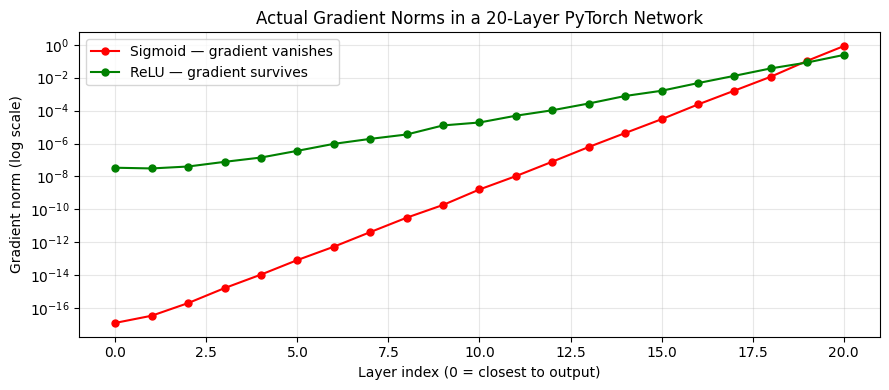

Sigmoid — grad norms (first 5 layers from output): ['1.28e-17', '3.51e-17', '2.05e-16', '1.66e-15', '1.10e-14']
ReLU    — grad norms (first 5 layers from output): ['3.40e-08', '3.08e-08', '4.04e-08', '7.75e-08', '1.42e-07']


In [6]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# Build a 20-layer network — once with Sigmoid, once with ReLU
def make_deep_net(activation, n_layers=20, width=32):
    layers = [nn.Flatten(), nn.Linear(width, width), activation()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(width, width), activation()]
    layers.append(nn.Linear(width, 1))
    return nn.Sequential(*layers)

net_sigmoid = make_deep_net(nn.Sigmoid)
net_relu    = make_deep_net(nn.ReLU)

# Dummy input and target
X_dummy = torch.randn(16, 32)
y_dummy = torch.randn(16, 1)
criterion = nn.MSELoss()

def get_grad_norms(model):
    # One forward + backward pass; collect grad norms per Linear layer
    model.zero_grad()
    loss = criterion(model(X_dummy), y_dummy)
    loss.backward()
    norms = []
    for m in model.modules():
        if isinstance(m, nn.Linear) and m.weight.grad is not None:
            norms.append(m.weight.grad.norm().item())
    return norms

norms_sig = get_grad_norms(net_sigmoid)
norms_relu = get_grad_norms(net_relu)

plt.figure(figsize=(9, 4))
plt.plot(norms_sig,  'r-o', markersize=5, label='Sigmoid — gradient vanishes')
plt.plot(norms_relu, 'g-o', markersize=5, label='ReLU — gradient survives')
plt.yscale('log')
plt.xlabel('Layer index (0 = closest to output)')
plt.ylabel('Gradient norm (log scale)')
plt.title('Actual Gradient Norms in a 20-Layer PyTorch Network')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Sigmoid — grad norms (first 5 layers from output):", [f'{v:.2e}' for v in norms_sig[:5]])
print("ReLU    — grad norms (first 5 layers from output):", [f'{v:.2e}' for v in norms_relu[:5]])

## 9.2 Weight Initialization

**Why it matters:** If weights start too large → activations saturate, gradients vanish. Too small → activations shrink to zero, no learning.

### Xavier Initialization (for Sigmoid/Tanh)
$$W \sim \mathcal{N}\left(0, \frac{1}{n_{\text{in}}}\right)$$

### He Initialization (for ReLU) ← most common today
$$W \sim \mathcal{N}\left(0, \frac{2}{n_{\text{in}}}\right)$$

The idea: keep the **variance of activations** roughly the same across all layers.


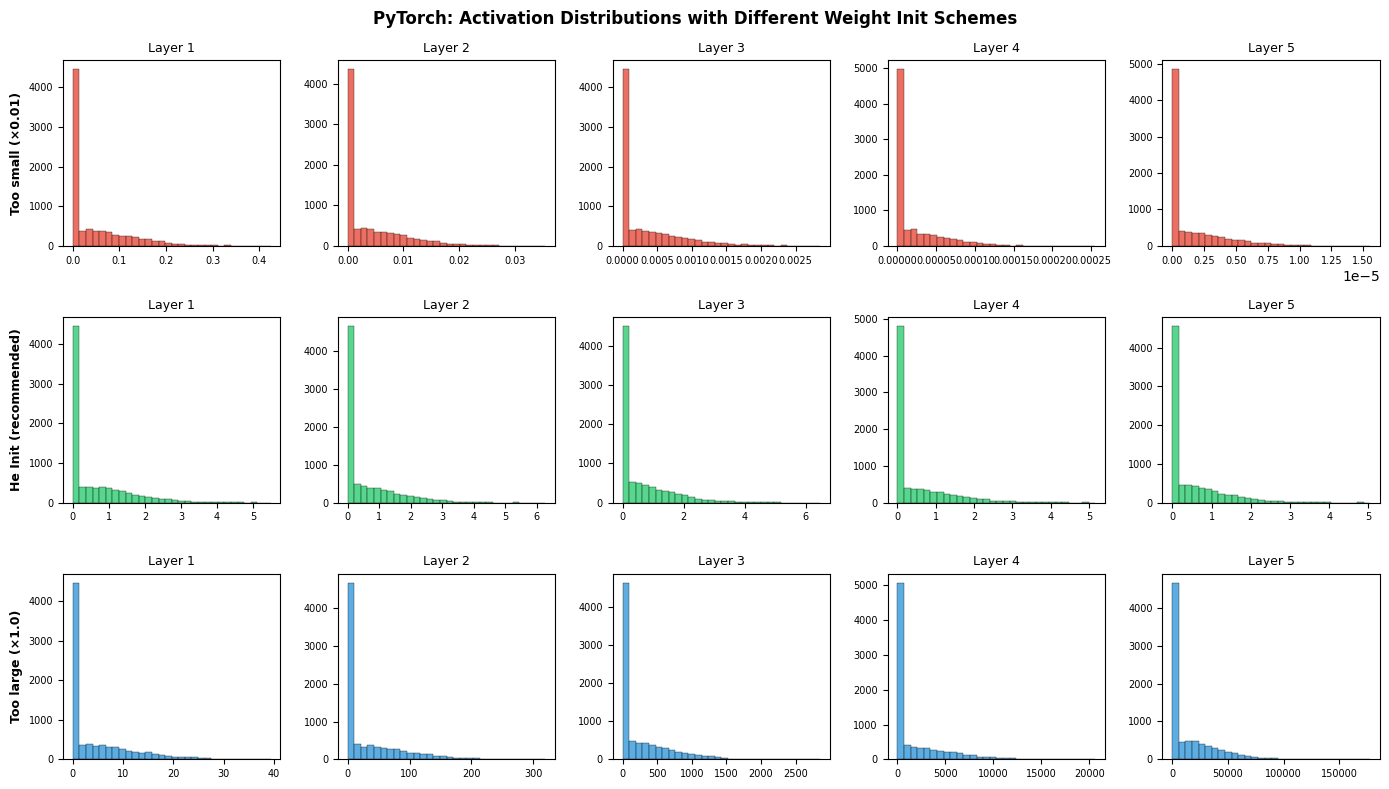

nn.init.kaiming_normal_  →  He init  (best for ReLU)
nn.init.xavier_normal_   →  Xavier init  (best for Sigmoid/Tanh)


In [8]:
torch.manual_seed(0)

def make_net_with_init(init_fn, n_layers=5, width=128):
    layers = []
    for i in range(n_layers):
        in_f  = 128 if i > 0 else 128
        layer = nn.Linear(in_f, width)
        init_fn(layer.weight)           # apply chosen init to weights
        nn.init.zeros_(layer.bias)      # biases always start at zero
        layers += [layer, nn.ReLU()]
    return nn.Sequential(*layers)

init_schemes = [
    ("Too small (×0.01)",    lambda w: nn.init.normal_(w, 0, 0.01)),
    ("He Init (recommended)", lambda w: nn.init.kaiming_normal_(w)),
    ("Too large (×1.0)",     lambda w: nn.init.normal_(w, 0, 1.0)),
]

x_pt = torch.randn(64, 128)   # batch of 64 samples

fig, axes = plt.subplots(3, 5, figsize=(14, 8))

for row, (name, init_fn) in enumerate(init_schemes):
    net = make_net_with_init(init_fn)
    activations = []

    # Hook to capture activations after each ReLU
    def hook(module, inp, out):
        activations.append(out.detach().numpy().flatten())
    for layer in net:
        if isinstance(layer, nn.ReLU):
            layer.register_forward_hook(hook)

    with torch.no_grad():
        net(x_pt)

    for col, act in enumerate(activations[:5]):
        axes[row, col].hist(act, bins=30, color=['#E74C3C','#2ECC71','#3498DB'][row],
                            alpha=0.8, edgecolor='k', lw=0.3)
        axes[row, col].set_title(f"Layer {col+1}", fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(name, fontsize=9, fontweight='bold')
        axes[row, col].tick_params(labelsize=7)

plt.suptitle("PyTorch: Activation Distributions with Different Weight Init Schemes",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("nn.init.kaiming_normal_  →  He init  (best for ReLU)")
print("nn.init.xavier_normal_   →  Xavier init  (best for Sigmoid/Tanh)")


## 9.3 Batch Normalization

**Idea:** After each layer, **normalize** the activations to have mean ≈ 0 and std ≈ 1.

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \cdot \gamma + \beta$$

Where $\mu_B$, $\sigma_B^2$ are the mean and variance of the current **mini-batch**.  
$\gamma$ and $\beta$ are **learnable** parameters (let the network undo normalization if needed).

**Benefits:**
- Reduces internal covariate shift
- Allows higher learning rates
- Acts as a regularizer (slight noise from batch statistics)
- Less sensitive to weight initialization


`nn.BatchNorm1d` handles all the math — including the learnable $\gamma$ and $\beta$, and the switch between training (batch statistics) and eval (running statistics) modes.


Before BN — mean: 2.78, std: 4.97
After  BN — mean: 0.0000, std: 1.0005

Learnable γ (gamma): [1. 1. 1. 1.] ...
Learnable β (beta):  [0. 0. 0. 0.] ...


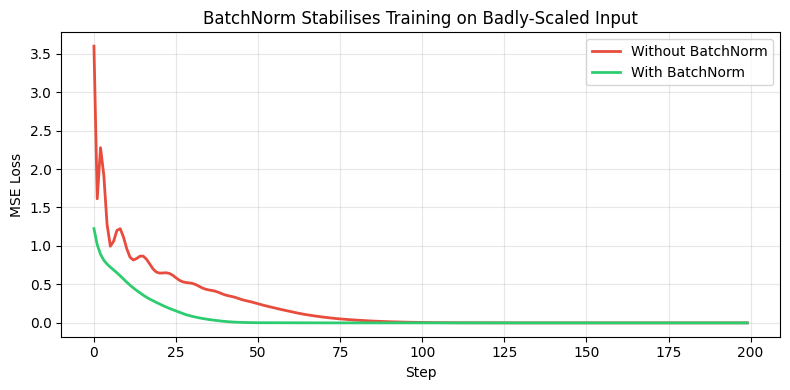

In [15]:
torch.manual_seed(1)

# Same off-distribution batch
batch_pt = torch.tensor(np.random.randn(64, 16) * 5 + 3, dtype=torch.float32)

bn_pt = nn.BatchNorm1d(num_features=16)   # γ and β are learnable params

bn_pt.train()                             # training mode: normalise over current batch
normalized_pt = bn_pt(batch_pt)

print(f"Before BN — mean: {batch_pt.mean():.2f}, std: {batch_pt.std():.2f}")
print(f"After  BN — mean: {normalized_pt.mean():.4f}, std: {normalized_pt.std():.4f}")
print(f"\nLearnable γ (gamma): {bn_pt.weight.data[:4].numpy().round(3)} ...")
print(f"Learnable β (beta):  {bn_pt.bias.data[:4].numpy().round(3)} ...")

# Show effect when BN is inside a network training loop
model_bn  = nn.Sequential(nn.Linear(16,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64,1))
model_no_bn = nn.Sequential(nn.Linear(16,64),                    nn.ReLU(), nn.Linear(64,1))

opt_bn    = torch.optim.Adam(model_bn.parameters(),    lr=0.01)
opt_no_bn = torch.optim.Adam(model_no_bn.parameters(), lr=0.01)
criterion_pt = nn.MSELoss()

X_bn = torch.randn(128, 16) * 5 + 3    # badly scaled input
y_bn = torch.randn(128, 1)

losses_bn, losses_no_bn = [], []
for _ in range(200):
    for model, opt, store in [(model_bn, opt_bn, losses_bn),
                               (model_no_bn, opt_no_bn, losses_no_bn)]:
        opt.zero_grad()
        loss = criterion_pt(model(X_bn), y_bn)
        loss.backward()
        opt.step()
        store.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses_no_bn, color='#E74C3C', lw=2, label='Without BatchNorm')
plt.plot(losses_bn,    color='#2ECC71', lw=2, label='With BatchNorm')
plt.title("BatchNorm Stabilises Training on Badly-Scaled Input")
plt.xlabel("Step"); plt.ylabel("MSE Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9.4 Overfitting: Dropout & Regularization

**Overfitting** = model memorizes training data, fails on new data.

### Dropout
During training, randomly **zero out** neurons with probability $p$ (typically 0.2–0.5).  
- Forces network not to rely on any single neuron
- Acts as an ensemble of many networks
- At test time, dropout is OFF (all neurons active, weights scaled)

### L2 Regularization (Weight Decay)
Add a penalty for large weights to the loss:

$$L_{\text{total}} = L_{\text{BCE}} + \lambda \sum_w w^2$$

This discourages the model from fitting noise.


`nn.Dropout` handles the inverted dropout and the train/eval switch automatically.  
Weight decay (L2) is passed directly to the optimizer as `weight_decay=`.


In [12]:
torch.manual_seed(0)

# ── Dropout ──
dropout_layer = nn.Dropout(p=0.5)   # p = probability of ZEROING (opposite convention to NumPy above!)

a_pt = torch.tensor([1.,2.,3.,4.,5.,6.,7.,8.])

dropout_layer.train()               # training mode → randomly zeros neurons
a_train_pt = dropout_layer(a_pt)

dropout_layer.eval()                # eval mode → passes through unchanged
a_eval_pt  = dropout_layer(a_pt)

print("=== nn.Dropout (p=0.5) ===")
print("Original:          ", a_pt.numpy())
print("Training mode:     ", a_train_pt.detach().numpy())
print("Eval mode:         ", a_eval_pt.detach().numpy())
print(f"Sum original:      {a_pt.sum():.1f}")
print(f"Sum training:      {a_train_pt.detach().sum():.1f}  (scaled survivors)")
print(f"Sum eval:          {a_eval_pt.detach().sum():.1f}")


=== nn.Dropout (p=0.5) ===
Original:           [1. 2. 3. 4. 5. 6. 7. 8.]
Training mode:      [ 0.  0.  6.  0.  0.  0. 14. 16.]
Eval mode:          [1. 2. 3. 4. 5. 6. 7. 8.]
Sum original:      36.0
Sum training:      36.0  (scaled survivors)
Sum eval:          36.0


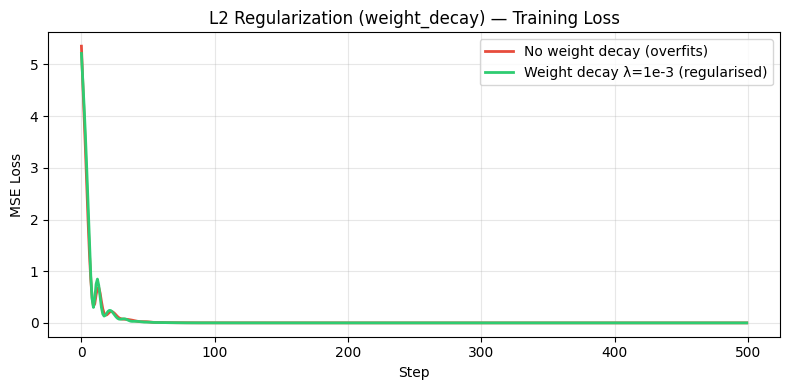

Total weight norm — no L2:  13.86
Total weight norm — with L2: 9.33  ← weights are smaller ✓


In [13]:
# ── Weight Decay (L2 regularization) via optimizer ──
torch.manual_seed(42)

# Synthetic data with noise — easy to overfit
X_reg = torch.randn(50, 8)
y_reg = X_reg[:, 0:1] * 2 + 0.5 * torch.randn(50, 1)   # only 1 of 8 features is relevant

def make_reg_model():
    return nn.Sequential(nn.Linear(8,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))

model_l2    = make_reg_model()
model_no_l2 = make_reg_model()

# weight_decay= adds L2 penalty: loss = MSE + λ * Σw²
opt_l2    = torch.optim.Adam(model_l2.parameters(),    lr=0.01, weight_decay=1e-3)
opt_no_l2 = torch.optim.Adam(model_no_l2.parameters(), lr=0.01, weight_decay=0)

crit = nn.MSELoss()
losses_l2, losses_no = [], []

for _ in range(500):
    for model, opt, store in [(model_l2, opt_l2, losses_l2),
                               (model_no_l2, opt_no_l2, losses_no)]:
        opt.zero_grad()
        loss = crit(model(X_reg), y_reg)
        loss.backward()
        opt.step()
        store.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses_no, color='#E74C3C', lw=2, label='No weight decay (overfits)')
plt.plot(losses_l2, color='#2ECC71', lw=2, label='Weight decay λ=1e-3 (regularised)')
plt.title("L2 Regularization (weight_decay) — Training Loss")
plt.xlabel("Step"); plt.ylabel("MSE Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Compare final weight magnitudes
no_l2_norm = sum(p.norm().item() for p in model_no_l2.parameters())
l2_norm    = sum(p.norm().item() for p in model_l2.parameters())
print(f"Total weight norm — no L2:  {no_l2_norm:.2f}")
print(f"Total weight norm — with L2: {l2_norm:.2f}  ← weights are smaller ✓")
